In [1]:
import numba
import os
import math
import numpy as np
import sqlite3
import time

def init_db(db_name='recursions.db'):
    try:
        conn = sqlite3.connect(db_name, timeout=60.0)
        c = conn.cursor()
        c.execute('''CREATE TABLE IF NOT EXISTS log_Q_states
                     (n INTEGER, b REAL, m_start INTEGER, L_prev BLOB, L BLOB, log_poch REAL,
                     PRIMARY KEY (n, b))''')
        c.execute('''CREATE TABLE IF NOT EXISTS log_Q_all_states
                     (n INTEGER, b REAL, m_start INTEGER, L_prev BLOB, L BLOB, res BLOB, log_poch REAL,
                     PRIMARY KEY (n, b))''')
        conn.commit()
        conn.close()
    except Exception:
        pass

def save_log_Q_state(n, b, m_start, L_prev, L, log_poch, db_name='recursions.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''INSERT OR REPLACE INTO log_Q_states (n, b, m_start, L_prev, L, log_poch)
                         VALUES (?, ?, ?, ?, ?, ?)''', 
                      (n, b, m_start, L_prev.tobytes(), L.tobytes(), log_poch))
            conn.commit()
            conn.close()
            break
        except sqlite3.OperationalError:
            time.sleep(2)

def load_log_Q_state(n, b, db_name='recursions.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''SELECT m_start, L_prev, L, log_poch FROM log_Q_states WHERE b=? AND m_start <= ? ORDER BY m_start DESC LIMIT 1''', (b, n + 2))
            row = c.fetchone()
            conn.close()
            if row is None:
                return None
            m_start = row[0]
            L_prev_old = np.frombuffer(row[1], dtype=np.float64)
            L_old = np.frombuffer(row[2], dtype=np.float64)
            log_poch = row[3]
            L_prev = np.zeros(n + 2, dtype=np.float64)
            L = np.zeros(n + 2, dtype=np.float64)
            L_prev[:len(L_prev_old)] = L_prev_old
            L[:len(L_old)] = L_old
            return m_start, L_prev, L, log_poch
        except sqlite3.OperationalError:
            time.sleep(2)
    return None

def save_log_Q_all_state(n, b, m_start, L_prev, L, res, log_poch, db_name='recursions.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''INSERT OR REPLACE INTO log_Q_all_states (n, b, m_start, L_prev, L, res, log_poch)
                         VALUES (?, ?, ?, ?, ?, ?, ?)''', 
                      (n, b, m_start, L_prev.tobytes(), L.tobytes(), res.tobytes(), log_poch))
            conn.commit()
            conn.close()
            break
        except sqlite3.OperationalError:
            time.sleep(2)

def load_log_Q_all_state(n, b, db_name='recursions.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''SELECT m_start, L_prev, L, res, log_poch FROM log_Q_all_states WHERE b=? AND m_start <= ? ORDER BY m_start DESC LIMIT 1''', (b, n + 2))
            row = c.fetchone()
            conn.close()
            if row is None:
                return None
            m_start = row[0]
            L_prev_old = np.frombuffer(row[1], dtype=np.float64)
            L_old = np.frombuffer(row[2], dtype=np.float64)
            res_old = np.frombuffer(row[3], dtype=np.float64)
            log_poch = row[4]
            L_prev = np.zeros(n + 2, dtype=np.float64)
            L = np.zeros(n + 2, dtype=np.float64)
            res = np.zeros(n + 1, dtype=np.float64)
            L_prev[:len(L_prev_old)] = L_prev_old
            L[:len(L_old)] = L_old
            res[:len(res_old)] = res_old
            return m_start, L_prev, L, res, log_poch
        except sqlite3.OperationalError:
            time.sleep(2)
    return None

@numba.njit
def logsumexp2(x, y):
    m = x if x > y else y
    return m + math.log(math.exp(x - m) + math.exp(y - m))

@numba.njit
def logsumexp_array(vals):
    m = np.max(vals)
    s = 0.0
    for i in range(len(vals)):
        s += math.exp(vals[i] - m)
    return m + math.log(s)

@numba.njit
def log1mexp_neg(x):
    return math.log(-math.expm1(x))

@numba.njit
def _log_Q_chunk(m_start, m_end, logb, L_prev, L):
    for m in range(m_start, m_end):
        L[m - 1] = logsumexp_array(L_prev[:m - 1])
        log1mbpow = log1mexp_neg((m - 1) * logb)
        for i in range(m - 1, 0, -1):
            t1 = logb + L[i]
            t2 = (1 - i) * logb + log1mbpow + L_prev[i - 1]
            L[i - 1] = logsumexp2(t1, t2)
        temp = L_prev
        L_prev = L
        L = temp
    return L_prev, L

@numba.njit
def _compute_log_poch(n, logb):
    log_poch = 0.0
    for k in range(1, n + 1):
        log_poch += log1mexp_neg(k * logb)
    return log_poch

def log_Q(n, b):
    if not (0.0 < b < 1.0):
        raise ValueError("b must lie in (0,1)")
    logb = math.log(b)
    init_db()
    state = load_log_Q_state(n, b)
    if state is not None:
        m_start, L_prev, L, log_poch = state
    else:
        m_start = 2
        L_prev = np.zeros(n + 2, dtype=np.float64)
        L = np.zeros(n + 2, dtype=np.float64)
        log_poch = 0.0

    chunk_size = 50000
    while m_start < n + 2:
        m_end = min(m_start + chunk_size, n + 2)
        L_prev, L = _log_Q_chunk(m_start, m_end, logb, L_prev, L)
        m_start = m_end
        save_log_Q_state(n, b, m_start, L_prev, L, log_poch)

    logH = L_prev[n]
    log_poch = _compute_log_poch(n, logb)
    return (n * (n + 1) // 2) * logb - 2.0 * log_poch + logH

@numba.njit
def _log_Q_all_chunk(m_start, m_end, logb, L_prev, L, res, log_poch):
    for m in range(m_start, m_end):
        L[m - 1] = logsumexp_array(L_prev[:m - 1])
        log1mbpow = log1mexp_neg((m - 1) * logb)
        for i in range(m - 1, 0, -1):
            t1 = logb + L[i]
            t2 = (1 - i) * logb + log1mbpow + L_prev[i - 1]
            L[i - 1] = logsumexp2(t1, t2)
        temp = L_prev
        L_prev = L
        L = temp
        num = m - 1
        logH_num = L_prev[num]
        log_poch += log1mexp_neg(num * logb)
        res[num] = (num * (num + 1) / 2.0) * logb - 2.0 * log_poch + logH_num
    return L_prev, L, res, log_poch

def log_Q_all(n, b):
    if not (0.0 < b < 1.0):
        raise ValueError("b must lie in (0,1)")
    logb = math.log(b)
    init_db()
    state = load_log_Q_all_state(n, b)
    if state is not None:
        m_start, L_prev, L, res, log_poch = state
    else:
        m_start = 2
        L_prev = np.zeros(n + 2, dtype=np.float64)
        L = np.zeros(n + 2, dtype=np.float64)
        res = np.zeros(n + 1, dtype=np.float64)
        log_poch = 0.0

    chunk_size = 50000
    while m_start < n + 2:
        m_end = min(m_start + chunk_size, n + 2)
        L_prev, L, res, log_poch = _log_Q_all_chunk(m_start, m_end, logb, L_prev, L, res, log_poch)
        m_start = m_end
        save_log_Q_all_state(n, b, m_start, L_prev, L, res, log_poch)

    return res


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed


def energy(n, w, verbose=False):
    """
    Computes the exact energy for n fermions in a 2D harmonic trap, 
    scaled by the effective relative frequency w.
    """
    # 1. Compute the standard base energy (w=1) using your exact state-filling logic
    cur_lvl = 0
    total_eng = 0
    m = n
    while n > 0:
        for i in range(0, cur_lvl):
            if n > 0:
                total_eng += cur_lvl - 1
                n -= 1
            else:
                break
        cur_lvl += 1
        
    base_energy = total_eng + m   
    
    if verbose:
        print("Highest shell: ", cur_lvl)
        
    # 2. Scale the relative energy component by w
    # For a 2D harmonic oscillator, the 1-particle CM energy is exactly 1.0
    e_1 = 1.0 
    
    true_energy_w = e_1 + w * (base_energy - e_1)
    
    return true_energy_w

# ==========================================
# 1. PA Propagator Functions
# ==========================================
def p_funcs_zeta_1(e):
    return 1.0 + (e**2) / 2.0

def p_funcs_lambda(e):
    return 1.0

def p_funcs_gamma(e):
    return math.sqrt(1.0 + (e**2) / 4.0)

def p_funcs_k1(e):
    return e

# ==========================================
# 2. Factor Calculations
# ==========================================
def factor_calc_T(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s):
    return (lambda_val / gamma_val), (w * lambda_val_s / gamma_val_s)

def factor_calc_H(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s):
    return 0.5 * (gamma_val + 1.0 / gamma_val), (w / 2.0) * (gamma_val_s + 1.0 / gamma_val_s)

# ==========================================
# 3. Top-Level Worker Function (Finite Diff)
# ==========================================
def _compute_estimators_worker_fd(args):
    tau_mid = args[0]
    tau_step = args[1]
    n = args[2]
    N = args[3]
    w = args[4]
    store_all_n = args[5] if len(args) > 5 else False
    
    # Left and right tau for the discrete derivative
    tau_1 = tau_mid - 0.5 * tau_step
    tau_2 = tau_mid + 0.5 * tau_step
    
    # --- A. Evaluate Factors at the midpoint ---
    if N == 0:
        fT_reg, fT_star = 1.0, 1.0
        fH_reg, fH_star = 1.0, 1.0
    else:
        epsilon = tau_mid / N
        eps_s = w * epsilon
        
        lambda_val = p_funcs_lambda(epsilon)
        gamma_val = p_funcs_gamma(epsilon)
        
        lambda_val_s = p_funcs_lambda(eps_s)
        zeta_1_s = p_funcs_zeta_1(eps_s)
        k1_s = p_funcs_k1(eps_s)
        
        # Guard against domain error in sqrt
        gamma_val_s = math.sqrt(max(0, zeta_1_s**2 - 1.0)) / k1_s
        
        fT_reg, fT_star = factor_calc_T(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s)
        fH_reg, fH_star = factor_calc_H(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s)
    
    # --- B. Compute Energies using YOUR Discrete Derivative ---
    def fd_log_Q(num_particles, b1, b2):
        """Finite difference derivative: [log_Q(tau1) - log_Q(tau2)] / step"""
        lq1 = log_Q(num_particles, b1)
        lq2 = log_Q(num_particles, b2)
        return (lq1 - lq2) / tau_step
        
    def fd_log_Q_all(num_particles, b1, b2):
        lq1 = log_Q_all(num_particles, b1)
        lq2 = log_Q_all(num_particles, b2)
        return (lq1 - lq2) / tau_step

    def get_b_val(tau_val, N_val, w_val):
        if N_val == 0:
            return math.exp(-w_val * abs(tau_val))
        eps = w_val * (tau_val / N_val)
        z1 = p_funcs_zeta_1(eps)
        u = math.acosh(z1) if z1 >= 1.0 else 0.0
        return math.exp(-N_val * u)
        
    b_tau1 = get_b_val(tau_1, N, 1.0)
    b_tau2 = get_b_val(tau_2, N, 1.0)
    
    b_s_tau1 = get_b_val(tau_1, N, w)
    b_s_tau2 = get_b_val(tau_2, N, w)

    if store_all_n:
        energy1_T = fd_log_Q(1, b_tau1, b_tau2)
        energystar_T_all = fd_log_Q_all(n, b_s_tau1, b_s_tau2) # shape (n+1,)
        energy1star_T = energystar_T_all[1]
        
        energy_T_all = energy1_T + (energystar_T_all - energy1star_T)
        
        energy1_H = energy1_T * (fH_reg / fT_reg)
        energystar_diff_H_all = (energystar_T_all - energy1star_T) * (fH_star / fT_star)
        energy_H_all = energy1_H + energystar_diff_H_all
        
        # We slice [1:] so index 0 is n=1, shape becomes (n,)
        return energy_T_all[1:], energy_H_all[1:]
    else:
        # Because these use finite difference w.r.t tau, these ARE the Thermodynamic energies!
        energy1_T     = fd_log_Q(1, b_tau1, b_tau2)
        energy1star_T = fd_log_Q(1, b_s_tau1, b_s_tau2)
        energystar_T  = fd_log_Q(n, b_s_tau1, b_s_tau2)
        
        # --- C. Assemble Final Estimators ---
        
        # 1. Total Thermodynamic Estimator
        # No factors needed here, the discrete derivative already contains them!
        energy_T = energy1_T + (energystar_T - energy1star_T)
        
        # 2. Total Hamiltonian Estimator
        # We apply your logic: multiply by inverse thermo factor (1/fT), then by Hamiltonian factor (fH)
        energy1_H = energy1_T * (fH_reg / fT_reg)
        energystar_diff_H = (energystar_T - energy1star_T) * (fH_star / fT_star)
        
        energy_H = energy1_H + energystar_diff_H
        
        return energy_T, energy_H

# ==========================================
# 4. Main Plotting & Saving Function
# ==========================================
def plot_fd_vs_tau_dual(n, N_list, w, tau_start, tau_end, tau_step, save_filename="plot_data", store_all_n=False, exact_b_exp_tau=False):
    if tau_step <= 0:
        raise ValueError("tau_step must be positive")
    if tau_end <= tau_start:
        raise ValueError("tau_end must be greater than tau_start")

    taus_left = np.arange(tau_start, tau_end, tau_step)
    taus_left = taus_left[taus_left + tau_step <= tau_end + 1e-15]
    taus_mid = taus_left + 0.5 * tau_step
    
    plt.figure(figsize=(10, 6))
    
    # Initialize dictionaries to hold our results for CSV
    results_T = {"tau_mid": taus_mid}
    results_H = {"tau_mid": taus_mid}
    
    results_T_all_n = []
    results_H_all_n = []
    
    if exact_b_exp_tau:
        N_list = list(N_list) + [0]
        
    for N in N_list:
        tasks = [(tau, tau_step, n, N, w, store_all_n) for tau in taus_mid]

        # Use joblib to compute estimators in parallel
        results = Parallel(n_jobs=-1)(delayed(_compute_estimators_worker_fd)(task) for task in tasks)
        
        energies_T = np.array([res[0] for res in results])
        energies_H = np.array([res[1] for res in results])
        
        if store_all_n:
            results_T_all_n.append(energies_T)
            results_H_all_n.append(energies_H)
            
            # Plot the highest n (index n-1)
            line, = plt.plot(taus_mid, energies_T[:, -1], label=f"N={N} (Thermo)")
            plt.plot(taus_mid, energies_H[:, -1], linestyle="--", color=line.get_color(), label=f"N={N} (Ham)")
        else:
            results_T[f"N_{N}"] = energies_T
            results_H[f"N_{N}"] = energies_H
            
            # Plot Thermodynamic as solid lines, Hamiltonian as dashed
            line, = plt.plot(taus_mid, energies_T, label=f"N={N} (Thermo)")
            plt.plot(taus_mid, energies_H, linestyle="--", color=line.get_color(), label=f"N={N} (Ham)")

    # Try to plot baseline energy if the `energy(n)` function is defined in your notebook
    try:
        e = energy(n,w)
        print(f"Exact energy for n={n}, w={w}: {e}")
        plt.axhline(e, linestyle=':', color='black', label=f"True Energy (n={n})")
    except NameError:
        pass 

    plt.xlabel(r"$\tau + \frac{1}{2}\,\Delta\tau$")
    plt.ylabel(r"Energy Estimators")
    plt.title(f"Thermodynamic (Solid) & Hamiltonian (Dashed) via Finite Difference\n(n={n}, w={w}, PA Propagator)")
    
    # Put legend outside the plot so it doesn't overlap lines
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adjust axes limits as needed based on your n
    try:
        e = energy(n,w)
        plt.ylim(e*0.95, e*1.05) 
    except:
        pass
        
    # plt.xlim(0, 15)
    
    plt.grid(True)
    plt.tight_layout()
    #plt.ylim(4650,5150)
    plt.show()
    
    if store_all_n:
        # Save as npy array with shape (n, num_beads, num_taus)
        arr_T = np.array(results_T_all_n).transpose(2, 0, 1)
        arr_H = np.array(results_H_all_n).transpose(2, 0, 1)
        
        np.save(f"{save_filename}_T_all_n.npy", arr_T)
        np.save(f"{save_filename}_H_all_n.npy", arr_H)
        
        # Save axes to separate files
        np.save(f"{save_filename}_taus.npy", taus_mid)
        np.save(f"{save_filename}_beads.npy", np.array(N_list))
        
        print(f"Data successfully saved to '{save_filename}_T_all_n.npy' (shape {arr_T.shape}) and '{save_filename}_H_all_n.npy' (shape {arr_H.shape})")
        print(f"Axes mapping: n (axis 0), beads (axis 1) -> '{save_filename}_beads.npy', taus (axis 2) -> '{save_filename}_taus.npy'")
        return arr_T, arr_H
    else:
        # Convert to pandas DataFrames and save to CSV
        df_T = pd.DataFrame(results_T)
        df_H = pd.DataFrame(results_H)
        
        df_T.to_csv(f"{save_filename}_T.csv", index=False)
        df_H.to_csv(f"{save_filename}_H.csv", index=False)
        
        print(f"Data successfully saved to '{save_filename}_T.csv' and '{save_filename}_H.csv'")
        
        return df_T, df_H


Exact energy for n=10000, w=1.0: 942820.0


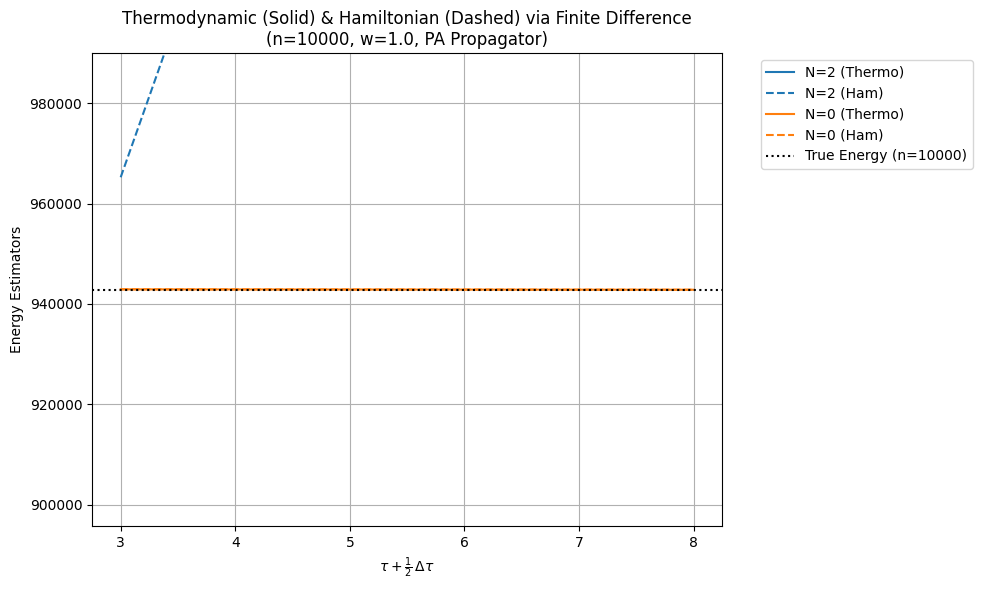

Data successfully saved to 'plot_data_n10000_w1_0_T_all_n.npy' (shape (10000, 2, 2)) and 'plot_data_n10000_w1_0_H_all_n.npy' (shape (10000, 2, 2))
Axes mapping: n (axis 0), beads (axis 1) -> 'plot_data_n10000_w1_0_beads.npy', taus (axis 2) -> 'plot_data_n10000_w1_0_taus.npy'


(array([[[1.16835182e+00, 4.59491387e-01],
         [1.37146279e+00, 1.00162704e+00]],
 
        [[2.95027578e+00, 1.37044576e+00],
         [3.55492617e+00, 3.00163372e+00]],
 
        [[4.90774034e+00, 2.28921072e+00],
         [5.91935714e+00, 5.00485799e+00]],
 
        ...,
 
        [[7.53123176e+05, 4.29283108e+05],
         [9.42621115e+05, 9.42538915e+05]],
 
        [[7.53236140e+05, 4.29347416e+05],
         [9.42762478e+05, 9.42679973e+05]],
 
        [[7.53349112e+05, 4.29411730e+05],
         [9.42903852e+05, 9.42821039e+05]]], shape=(10000, 2, 2)),
 array([[[1.49695077e+00, 1.37847416e+00],
         [1.37146279e+00, 1.00162704e+00]],
 
        [[3.78004085e+00, 4.11133728e+00],
         [3.55492617e+00, 3.00163372e+00]],
 
        [[6.28804232e+00, 6.86763215e+00],
         [5.91935714e+00, 5.00485799e+00]],
 
        ...,
 
        [[9.64939069e+05, 1.28784933e+06],
         [9.42621115e+05, 9.42538915e+05]],
 
        [[9.65083805e+05, 1.28804225e+06],
         [9.4276

In [4]:
N_list = [2]
n = 10000
w = 1.0

plot_fd_vs_tau_dual(
    n=n,
    N_list=N_list,
    w=w,
    tau_start=0.5,
    tau_end=10.5,
    tau_step=5,
    save_filename=f"plot_data_n{n}_w{str(w).replace('.', '_')}", 
    store_all_n=True,
    exact_b_exp_tau=True
)


Loaded arrays with shapes:
T_all_n: (300, 4, 398)
H_all_n: (300, 4, 398)
taus: (398,)
beads: (4,)

 Extracting data for n=300 (index 299) and bead=4 (index 1)
Successfully exported to extracted_n300_bead4.csv
 


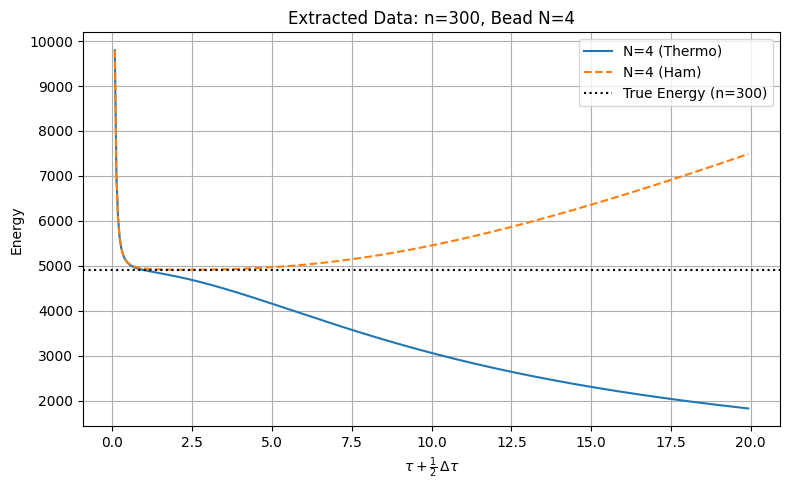

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the saved 3D arrays and axes
# Change save_filename if you used a different name in plot_fd_vs_tau_dual
n_val = 300
w_val = 1.0
save_filename = f"plot_data_n{n_val}_w{str(w_val).replace('.', '_')}"  

try:
    arr_T = np.load(f"{save_filename}_T_all_n.npy")
    arr_H = np.load(f"{save_filename}_H_all_n.npy")
    taus = np.load(f"{save_filename}_taus.npy")
    beads = np.load(f"{save_filename}_beads.npy")
    
    print(f"Loaded arrays with shapes:")
    print(f"T_all_n: {arr_T.shape}")
    print(f"H_all_n: {arr_H.shape}")
    print(f"taus: {taus.shape}")
    print(f"beads: {beads.shape}")
    
    # ==========================================
    # Define the target n and bead you want to extract
    # ==========================================
    target_n = 300   # Example: n=2
    target_bead = 4  # Example: N=4
    
    # 1. Find the correct indices
    # Remember that array index 0 corresponds to n=1, so index = target_n - 1
    n_idx = target_n - 1
    
    # Find the index in the beads array that matches target_bead
    bead_idx = np.where(beads == target_bead)[0][0]
    
    print(f"\n Extracting data for n={target_n} (index {n_idx}) and bead={target_bead} (index {bead_idx})")
    
    # 2. Extract the 1D arrays for tau vs energy
    energy_T = arr_T[n_idx, bead_idx, :]
    energy_H = arr_H[n_idx, bead_idx, :]
    
    # 3. Save this specific 1D slice to a CSV file
    df_extracted = pd.DataFrame({
        "tau_mid": taus,
        "Energy_Thermodynamic": energy_T,
        "Energy_Hamiltonian": energy_H
    })
    export_filename = f"extracted_n{target_n}_bead{target_bead}.csv"
    df_extracted.to_csv(export_filename, index=False)
    print(f"Successfully exported to {export_filename}\n ")
    
    # 4. Plot to verify
    plt.figure(figsize=(8, 5))
    plt.plot(taus, energy_T, label=f"N={target_bead} (Thermo)", linestyle="-")
    plt.plot(taus, energy_H, label=f"N={target_bead} (Ham)", linestyle="--")
    
    # Try to plot baseline energy if the `energy(n)` function is defined
    try:
        e = energy(target_n, w=1.0)
        plt.axhline(e, linestyle=':', color='black', label=f"True Energy (n={target_n})")
    except NameError:
        pass 
    
    plt.xlabel(r"$\tau + \frac{1}{2}\,\Delta\tau$")
    plt.ylabel(r"Energy")
    plt.title(f"Extracted Data: n={target_n}, Bead N={target_bead}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the files starting with '{save_filename}'.")
    print("Please make sure you have run plot_fd_vs_tau_dual with store_all_n=True first!")
